# 12 — AIA ResNet18 Multifold Error Analysis and Research Log Update

**Purpose.** This notebook performs a CPU-only post-training error analysis for the physics-safe ResNet18 hyperparameter sensitivity experiment.

It uses the outputs already produced by Notebook 12:

- `results/metrics/aia_resnet18_hp_sensitivity_multifold_all_results.csv`
- `results/metrics/aia_resnet18_hp_sensitivity_multifold_config_summary.csv`
- `results/metrics/aia_resnet18_hp_sensitivity_multifold_selection_summary.json`
- per-config/fold prediction files:
  - `*_test_predictions.csv`
  - `*_val_predictions.csv`
  - `*_test_samples.csv`
  - `*_val_samples.csv`
  - `*_test_threshold_grid.csv`
  - `*_val_threshold_grid.csv`

**No model training is performed here.**  
This notebook should run quickly on CPU and can be run before stopping the VM.

## Key protocol reminder

Hyperparameter selection was based only on **mean validation TSS across folds**.  
Test metrics are analysed after selection and must not be used to choose a new configuration.


In [1]:
from pathlib import Path
import json
import math
import warnings
from datetime import datetime

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

ROOT = Path("/home/abmoses2000/solar_flare_aia")
METRICS_DIR = ROOT / "results" / "metrics"
FIG_DIR = ROOT / "results" / "figures"
OUT_DIR = METRICS_DIR

FIG_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

EXPERIMENT_PREFIX = "aia_resnet18_hp_sensitivity"
NB_NAME = "12_aia_resnet18_multifold_error_analysis_and_research_log_update"

print("ROOT:", ROOT)
print("METRICS_DIR exists:", METRICS_DIR.exists())
print("FIG_DIR exists:", FIG_DIR.exists())
print("Started:", datetime.now().isoformat(timespec="seconds"))


ROOT: /home/abmoses2000/solar_flare_aia
METRICS_DIR exists: True
FIG_DIR exists: True
Started: 2026-08-03T12:36:23


## 1. Load Notebook 12 summary outputs

In [2]:
summary_path = METRICS_DIR / "aia_resnet18_hp_sensitivity_multifold_all_results.csv"
config_summary_path = METRICS_DIR / "aia_resnet18_hp_sensitivity_multifold_config_summary.csv"
selection_path = METRICS_DIR / "aia_resnet18_hp_sensitivity_multifold_selection_summary.json"
interpretation_path = METRICS_DIR / "aia_resnet18_hp_sensitivity_multifold_interpretation.md"

required = [summary_path, config_summary_path, selection_path]
missing = [str(p) for p in required if not p.exists()]
if missing:
    raise FileNotFoundError("Missing required Notebook 12 output(s):\n" + "\n".join(missing))

all_results = pd.read_csv(summary_path)
config_summary = pd.read_csv(config_summary_path)
with open(selection_path, "r") as f:
    selection = json.load(f)

selected_config = (
    selection.get("selected_config")
    or selection.get("selected_config_by_validation")
    or selection.get("best_config")
    or "higher_dropout"
)

print("Loaded all_results:", all_results.shape)
print("Loaded config_summary:", config_summary.shape)
print("Selected config:", selected_config)

display_cols = [
    "config_name", "fold_id", "source_kind", "train_rows", "val_rows", "test_rows",
    "test_positives", "selected_threshold", "val_tss", "test_roc_auc",
    "test_pr_auc", "test_precision", "test_recall", "test_specificity", "test_tss", "test_hss",
    "test_tp", "test_tn", "test_fp", "test_fn"
]
display(all_results[[c for c in display_cols if c in all_results.columns]])


Loaded all_results: (12, 30)
Loaded config_summary: (4, 30)
Selected config: higher_dropout


,config_name,fold_id,source_kind,train_rows,val_rows,test_rows,test_positives,selected_threshold,val_tss,test_roc_auc,test_pr_auc,test_precision,test_recall,test_specificity,test_tss,test_hss,test_tp,test_tn,test_fp,test_fn
0,baseline_existing,test_2013,existing_baseline,14448,10815,13066,492,0.0500,0.1854,0.6592,0.0563,0.0548,0.7378,0.5024,0.2402,0.0344,363,6317,6257,129
1,baseline_existing,test_2014,existing_baseline,25263,13066,11627,629,0.0075,0.2093,0.4975,0.0541,0.0552,0.3847,0.6234,0.0081,0.0021,242,6856,4142,387
2,baseline_existing,test_2015,existing_baseline,38329,11627,11236,531,0.2050,0.2997,0.7477,0.0971,0.0941,0.8682,0.5852,0.4534,0.0923,461,6265,4440,70
3,higher_dropout,test_2013,trained_tuning_config,14448,10815,13066,492,0.0225,0.2150,0.6408,0.0974,0.0496,0.6057,0.5455,0.1512,0.0237,298,6859,5715,194
4,higher_dropout,test_2014,trained_tuning_config,25263,13066,11627,629,0.5975,0.2519,0.5960,0.0692,0.0731,0.2146,0.8442,0.0589,0.0308,135,9285,1713,494
5,higher_dropout,test_2015,trained_tuning_config,38329,11627,11236,531,0.1275,0.2539,0.6563,0.0740,0.0800,0.7815,0.5541,0.3357,0.0650,415,5932,4773,116
6,lower_lr,test_2013,trained_tuning_config,14448,10815,13066,492,0.0250,0.2250,0.5988,0.0571,0.0502,0.5203,0.6147,0.1350,0.0245,256,7729,4845,236
7,lower_lr,test_2014,trained_tuning_config,25263,13066,11627,629,0.0075,0.2266,0.4667,0.0539,0.0438,0.3514,0.5608,-0.0878,-0.0204,221,6168,4830,408
8,lower_lr,test_2015,trained_tuning_config,38329,11627,11236,531,0.2225,0.1891,0.7209,0.0956,0.0807,0.6761,0.6179,0.2940,0.0652,359,6615,4090,172
9,reduced_pos_weight,test_2013,trained_tuning_config,14448,10815,13066,492,0.0650,0.1922,0.6542,0.0559,0.0512,0.7967,0.4229,0.2196,0.0275,392,5317,7257,100


## 2. Recompute core error quantities from the official confusion matrices

In [3]:
def safe_div(a, b):
    return np.nan if b in (0, 0.0) or pd.isna(b) else a / b

err_rows = []
for _, r in all_results.iterrows():
    tp = int(r.get("test_tp", 0))
    tn = int(r.get("test_tn", 0))
    fp = int(r.get("test_fp", 0))
    fn = int(r.get("test_fn", 0))
    pos = tp + fn
    neg = tn + fp
    total = pos + neg

    diagnostic_best = r.get("diagnostic_test_best_tss", np.nan)
    official_tss = r.get("test_tss", np.nan)

    err_rows.append({
        "config_name": r.get("config_name"),
        "source_kind": r.get("source_kind"),
        "fold_id": r.get("fold_id"),
        "train_rows": r.get("train_rows"),
        "val_rows": r.get("val_rows"),
        "test_rows": r.get("test_rows"),
        "test_positives": pos,
        "test_negatives": neg,
        "test_positive_rate": safe_div(pos, total),
        "selected_threshold": r.get("selected_threshold"),
        "test_tp": tp,
        "test_tn": tn,
        "test_fp": fp,
        "test_fn": fn,
        "false_alarm_rate": safe_div(fp, neg),
        "miss_rate": safe_div(fn, pos),
        "fp_per_tp": safe_div(fp, tp),
        "fn_per_tp": safe_div(fn, tp),
        "predicted_positive_rate": safe_div(tp + fp, total),
        "predicted_negative_rate": safe_div(tn + fn, total),
        "test_precision": r.get("test_precision"),
        "test_recall": r.get("test_recall"),
        "test_specificity": r.get("test_specificity"),
        "test_tss": official_tss,
        "test_hss": r.get("test_hss"),
        "test_roc_auc": r.get("test_roc_auc"),
        "test_pr_auc": r.get("test_pr_auc"),
        "diagnostic_test_best_tss": diagnostic_best,
        "diagnostic_minus_official_tss": diagnostic_best - official_tss,
    })

error_summary = pd.DataFrame(err_rows)

out_error_summary = OUT_DIR / "aia_resnet18_multifold_error_analysis_confusion_summary.csv"
error_summary.to_csv(out_error_summary, index=False)

print("Saved:", out_error_summary)
display(error_summary.sort_values(["config_name", "fold_id"]))


Saved: /home/abmoses2000/solar_flare_aia/results/metrics/aia_resnet18_multifold_error_analysis_confusion_summary.csv


,config_name,source_kind,fold_id,train_rows,val_rows,test_rows,test_positives,test_negatives,test_positive_rate,selected_threshold,...,predicted_negative_rate,test_precision,test_recall,test_specificity,test_tss,test_hss,test_roc_auc,test_pr_auc,diagnostic_test_best_tss,diagnostic_minus_official_tss
0,baseline_existing,existing_baseline,test_2013,14448,10815,13066,492,12574,0.037655,0.0500,...,0.493341,0.0548,0.7378,0.5024,0.2402,0.0344,0.6592,0.0563,0.2538,0.0136
1,baseline_existing,existing_baseline,test_2014,25263,13066,11627,629,10998,0.054098,0.0075,...,0.622947,0.0552,0.3847,0.6234,0.0081,0.0021,0.4975,0.0541,0.0092,0.0011
2,baseline_existing,existing_baseline,test_2015,38329,11627,11236,531,10705,0.047259,0.2050,...,0.563813,0.0941,0.8682,0.5852,0.4534,0.0923,0.7477,0.0971,0.4560,0.0026
3,higher_dropout,trained_tuning_config,test_2013,14448,10815,13066,492,12574,0.037655,0.0225,...,0.539798,0.0496,0.6057,0.5455,0.1512,0.0237,0.6408,0.0974,0.2406,0.0894
4,higher_dropout,trained_tuning_config,test_2014,25263,13066,11627,629,10998,0.054098,0.5975,...,0.841060,0.0731,0.2146,0.8442,0.0589,0.0308,0.5960,0.0692,0.2064,0.1475
5,higher_dropout,trained_tuning_config,test_2015,38329,11627,11236,531,10705,0.047259,0.1275,...,0.538270,0.0800,0.7815,0.5541,0.3357,0.0650,0.6563,0.0740,0.3409,0.0052
6,lower_lr,trained_tuning_config,test_2013,14448,10815,13066,492,12574,0.037655,0.0250,...,0.609597,0.0502,0.5203,0.6147,0.1350,0.0245,0.5988,0.0571,0.1533,0.0183
7,lower_lr,trained_tuning_config,test_2014,25263,13066,11627,629,10998,0.054098,0.0075,...,0.565580,0.0438,0.3514,0.5608,-0.0878,-0.0204,0.4667,0.0539,0.0472,0.1350
8,lower_lr,trained_tuning_config,test_2015,38329,11627,11236,531,10705,0.047259,0.2225,...,0.604041,0.0807,0.6761,0.6179,0.2940,0.0652,0.7209,0.0956,0.3275,0.0335
9,reduced_pos_weight,trained_tuning_config,test_2013,14448,10815,13066,492,12574,0.037655,0.0650,...,0.414587,0.0512,0.7967,0.4229,0.2196,0.0275,0.6542,0.0559,0.2315,0.0119


## 3. Identify fold-level failure modes

In [4]:
fold_hardness = (
    error_summary
    .groupby("fold_id", as_index=False)
    .agg(
        n_configs=("config_name", "count"),
        mean_test_tss=("test_tss", "mean"),
        std_test_tss=("test_tss", "std"),
        mean_recall=("test_recall", "mean"),
        mean_specificity=("test_specificity", "mean"),
        mean_false_alarm_rate=("false_alarm_rate", "mean"),
        mean_miss_rate=("miss_rate", "mean"),
        mean_fp_per_tp=("fp_per_tp", "mean"),
        mean_fn_per_tp=("fn_per_tp", "mean"),
        test_positive_rate=("test_positive_rate", "mean"),
    )
    .sort_values("mean_test_tss")
)

out_fold_hardness = OUT_DIR / "aia_resnet18_multifold_error_analysis_fold_hardness.csv"
fold_hardness.to_csv(out_fold_hardness, index=False)

print("Saved:", out_fold_hardness)
display(fold_hardness)


Saved: /home/abmoses2000/solar_flare_aia/results/metrics/aia_resnet18_multifold_error_analysis_fold_hardness.csv


,fold_id,n_configs,mean_test_tss,std_test_tss,mean_recall,mean_specificity,mean_false_alarm_rate,mean_miss_rate,mean_fp_per_tp,mean_fn_per_tp,test_positive_rate
1,test_2014,4,0.003850,0.064536,0.328700,0.675125,0.324855,0.671304,16.851630,2.212828,0.054098
0,test_2013,4,0.186500,0.051243,0.665125,0.521375,0.478646,0.334858,18.463326,0.545839,0.037655
2,test_2015,4,0.374475,0.072652,0.813550,0.560875,0.439094,0.186441,10.919839,0.246887,0.047259


## 4. Threshold transfer analysis: validation-selected vs test diagnostic best

In [5]:
threshold_cols = [
    "config_name", "fold_id", "selected_threshold", "val_tss", "test_tss",
    "diagnostic_test_best_tss", "diagnostic_minus_official_tss",
    "test_precision", "test_recall", "test_specificity",
    "test_tp", "test_tn", "test_fp", "test_fn"
]

threshold_transfer = error_summary[[c for c in threshold_cols if c in error_summary.columns]].copy()
threshold_transfer = threshold_transfer.sort_values("diagnostic_minus_official_tss", ascending=False)

out_threshold_transfer = OUT_DIR / "aia_resnet18_multifold_error_analysis_threshold_transfer.csv"
threshold_transfer.to_csv(out_threshold_transfer, index=False)

print("Saved:", out_threshold_transfer)
display(threshold_transfer)


Saved: /home/abmoses2000/solar_flare_aia/results/metrics/aia_resnet18_multifold_error_analysis_threshold_transfer.csv


,config_name,fold_id,selected_threshold,test_tss,diagnostic_test_best_tss,diagnostic_minus_official_tss,test_precision,test_recall,test_specificity,test_tp,test_tn,test_fp,test_fn
4,higher_dropout,test_2014,0.5975,0.0589,0.2064,0.1475,0.0731,0.2146,0.8442,135,9285,1713,494
7,lower_lr,test_2014,0.0075,-0.0878,0.0472,0.1350,0.0438,0.3514,0.5608,221,6168,4830,408
3,higher_dropout,test_2013,0.0225,0.1512,0.2406,0.0894,0.0496,0.6057,0.5455,298,6859,5715,194
10,reduced_pos_weight,test_2014,0.0100,0.0362,0.0801,0.0439,0.0597,0.3641,0.6721,229,7392,3606,400
8,lower_lr,test_2015,0.2225,0.2940,0.3275,0.0335,0.0807,0.6761,0.6179,359,6615,4090,172
6,lower_lr,test_2013,0.0250,0.1350,0.1533,0.0183,0.0502,0.5203,0.6147,256,7729,4845,236
0,baseline_existing,test_2013,0.0500,0.2402,0.2538,0.0136,0.0548,0.7378,0.5024,363,6317,6257,129
9,reduced_pos_weight,test_2013,0.0650,0.2196,0.2315,0.0119,0.0512,0.7967,0.4229,392,5317,7257,100
11,reduced_pos_weight,test_2015,0.1450,0.4148,0.4248,0.0100,0.0823,0.9284,0.4863,493,5206,5499,38
5,higher_dropout,test_2015,0.1275,0.3357,0.3409,0.0052,0.0800,0.7815,0.5541,415,5932,4773,116


## 5. Load prediction files and label-level errors

In [6]:
def find_prediction_bundle(config_name, fold_id, split):
    pred = METRICS_DIR / f"aia_resnet18_hp_sensitivity_{config_name}_{fold_id}_{split}_predictions.csv"
    samples = METRICS_DIR / f"aia_resnet18_hp_sensitivity_{config_name}_{fold_id}_{split}_samples.csv"
    grid = METRICS_DIR / f"aia_resnet18_hp_sensitivity_{config_name}_{fold_id}_{split}_threshold_grid.csv"

    if config_name == "baseline_existing":
        candidates_pred = [
            METRICS_DIR / f"aia_resnet18_physics_safe_multifold_fullnatural_{fold_id}_{split}_predictions.csv",
            METRICS_DIR / f"aia_resnet18_physics_safe_{fold_id}_{split}_predictions.csv",
            METRICS_DIR / f"aia_resnet18_physics_safe_fold2015_fullnatural_benchmark_fullnatural_physics_safe_{split}_predictions.csv",
        ]
        candidates_samples = [
            METRICS_DIR / f"aia_resnet18_physics_safe_multifold_fullnatural_{fold_id}_{split}_samples.csv",
            METRICS_DIR / f"aia_resnet18_physics_safe_{fold_id}_{split}_samples.csv",
            METRICS_DIR / f"aia_resnet18_physics_safe_fold2015_fullnatural_benchmark_fullnatural_physics_safe_{split}_samples.csv",
        ]
        candidates_grid = [
            METRICS_DIR / f"aia_resnet18_physics_safe_multifold_fullnatural_{fold_id}_{split}_threshold_grid.csv",
            METRICS_DIR / f"aia_resnet18_physics_safe_{fold_id}_{split}_threshold_grid.csv",
            METRICS_DIR / f"aia_resnet18_physics_safe_fold2015_fullnatural_benchmark_fullnatural_physics_safe_{split}_threshold_grid.csv",
        ]
        pred = next((p for p in candidates_pred if p.exists()), pred)
        samples = next((p for p in candidates_samples if p.exists()), samples)
        grid = next((p for p in candidates_grid if p.exists()), grid)

    return pred, samples, grid

def infer_probability_column(df):
    candidates = ["prob", "probability", "y_prob", "p", "score", "pred_prob", "prediction", "logit_sigmoid"]
    for c in candidates:
        if c in df.columns:
            return c
    numeric = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
    numeric = [c for c in numeric if c not in {"y", "label", "target", "pred", "y_pred", "index"}]
    if not numeric:
        raise ValueError("Could not infer probability column from columns: " + ", ".join(df.columns))
    return numeric[0]

def infer_label_column(df):
    candidates = ["y_true", "label", "target", "y", "label_48h_final"]
    for c in candidates:
        if c in df.columns:
            return c
    raise ValueError("Could not infer label column from columns: " + ", ".join(df.columns))

bundles = []
for _, r in all_results.iterrows():
    config = r["config_name"]
    fold = r["fold_id"]
    threshold = float(r["selected_threshold"])

    pred_path, sample_path, grid_path = find_prediction_bundle(config, fold, "test")
    if not pred_path.exists():
        continue

    pred_df = pd.read_csv(pred_path)
    prob_col = infer_probability_column(pred_df)

    if any(c in pred_df.columns for c in ["y_true", "label", "target", "y", "label_48h_final"]):
        label_col = infer_label_column(pred_df)
        y_true = pred_df[label_col].astype(int).values
    elif sample_path.exists():
        sample_df_tmp = pd.read_csv(sample_path)
        label_col = infer_label_column(sample_df_tmp)
        y_true = sample_df_tmp[label_col].astype(int).values
    else:
        raise ValueError(f"No label column in {pred_path} and sample missing")

    prob = pred_df[prob_col].astype(float).values
    y_pred = (prob >= threshold).astype(int)

    labelled = pred_df.copy()
    labelled["config_name"] = config
    labelled["fold_id"] = fold
    labelled["selected_threshold"] = threshold
    labelled["y_true_error_analysis"] = y_true
    labelled["prob_error_analysis"] = prob
    labelled["y_pred_error_analysis"] = y_pred
    labelled["error_type"] = np.select(
        [
            (y_true == 1) & (y_pred == 1),
            (y_true == 0) & (y_pred == 0),
            (y_true == 0) & (y_pred == 1),
            (y_true == 1) & (y_pred == 0),
        ],
        ["TP", "TN", "FP", "FN"],
        default="UNKNOWN",
    )

    if sample_path.exists():
        sample_df = pd.read_csv(sample_path)
        sample_prefixed = sample_df.add_prefix("sample_")
        labelled = pd.concat([labelled.reset_index(drop=True), sample_prefixed.reset_index(drop=True)], axis=1)

    bundles.append(labelled)

if not bundles:
    print("No prediction files found. Detailed sample-level error analysis is skipped.")
    all_labelled_errors = pd.DataFrame()
else:
    all_labelled_errors = pd.concat(bundles, ignore_index=True)
    out_labelled = OUT_DIR / "aia_resnet18_multifold_error_analysis_labelled_test_predictions.csv"
    all_labelled_errors.to_csv(out_labelled, index=False)
    print("Saved:", out_labelled)
    print("Labelled predictions:", all_labelled_errors.shape)
    display(all_labelled_errors[["config_name", "fold_id", "error_type", "y_true_error_analysis", "prob_error_analysis", "y_pred_error_analysis"]].head())


Saved: /home/abmoses2000/solar_flare_aia/results/metrics/aia_resnet18_multifold_error_analysis_labelled_test_predictions.csv
Labelled predictions: (143716, 19)


,config_name,fold_id,error_type,y_true_error_analysis,prob_error_analysis,y_pred_error_analysis
0,baseline_existing,test_2013,TN,0,0.004660,0
1,baseline_existing,test_2013,TN,0,0.005416,0
2,baseline_existing,test_2013,TN,0,0.015431,0
3,baseline_existing,test_2013,TN,0,0.003410,0
4,baseline_existing,test_2013,FP,0,0.375790,1


## 6. High-confidence false positives and false negatives

In [7]:
if all_labelled_errors.empty:
    print("Skipping top-error sample export because no labelled prediction files were loaded.")
else:
    selected_errors = all_labelled_errors[all_labelled_errors["config_name"] == selected_config].copy()
    if selected_errors.empty:
        selected_errors = all_labelled_errors.copy()

    top_fp = (
        selected_errors[selected_errors["error_type"] == "FP"]
        .sort_values("prob_error_analysis", ascending=False)
        .head(100)
    )
    top_fn = (
        selected_errors[selected_errors["error_type"] == "FN"]
        .sort_values("prob_error_analysis", ascending=True)
        .head(100)
    )

    out_fp = OUT_DIR / "aia_resnet18_multifold_error_analysis_top_false_positives_selected_config.csv"
    out_fn = OUT_DIR / "aia_resnet18_multifold_error_analysis_top_false_negatives_selected_config.csv"
    top_fp.to_csv(out_fp, index=False)
    top_fn.to_csv(out_fn, index=False)

    print("Selected config for sample-level error lists:", selected_config)
    print("Saved:", out_fp, "rows:", len(top_fp))
    print("Saved:", out_fn, "rows:", len(top_fn))

    display(top_fp.head(10))
    display(top_fn.head(10))


Selected config for sample-level error lists: higher_dropout
Saved: /home/abmoses2000/solar_flare_aia/results/metrics/aia_resnet18_multifold_error_analysis_top_false_positives_selected_config.csv rows: 100
Saved: /home/abmoses2000/solar_flare_aia/results/metrics/aia_resnet18_multifold_error_analysis_top_false_negatives_selected_config.csv rows: 100


,gcp_path,y_true,y_prob,config_name,fold_id,selected_threshold,y_true_error_analysis,prob_error_analysis,y_pred_error_analysis,error_type,sample_fold_id,sample_split,sample_gcp_path,sample_sample_id,sample_T_REC_dt,sample_HARPNUM,sample_NOAA_AR_clean,sample_label_48h_final,sample_year
53685,gs://suryabench-sharp-pipeline-bamidele/sample...,0,0.955353,higher_dropout,test_2014,0.5975,0,0.955353,1,FP,test_2015,test,gs://suryabench-sharp-pipeline-bamidele/sample...,20140320_0248_HARP3848_NOAA12005,2014-03-20 02:48:00,3848.0,12005.0,0.0,2014.0
56962,gs://suryabench-sharp-pipeline-bamidele/sample...,0,0.947513,higher_dropout,test_2014,0.5975,0,0.947513,1,FP,test_2015,test,gs://suryabench-sharp-pipeline-bamidele/sample...,20140320_2224_HARP3848_NOAA12005,2014-03-20 22:24:00,3848.0,12005.0,0.0,2014.0
53952,gs://suryabench-sharp-pipeline-bamidele/sample...,0,0.941184,higher_dropout,test_2014,0.5975,0,0.941184,1,FP,test_2015,test,gs://suryabench-sharp-pipeline-bamidele/sample...,20140321_0836_HARP3848_NOAA12005,2014-03-21 08:36:00,3848.0,12005.0,0.0,2014.0
56311,gs://suryabench-sharp-pipeline-bamidele/sample...,0,0.938864,higher_dropout,test_2014,0.5975,0,0.938864,1,FP,test_2015,test,gs://suryabench-sharp-pipeline-bamidele/sample...,20140320_1112_HARP3848_NOAA12005,2014-03-20 11:12:00,3848.0,12005.0,0.0,2014.0
60334,gs://suryabench-sharp-pipeline-bamidele/sample...,0,0.931048,higher_dropout,test_2014,0.5975,0,0.931048,1,FP,test_2015,test,gs://suryabench-sharp-pipeline-bamidele/sample...,20140313_0612_HARP3836_NOAA12002,2014-03-13 06:12:00,3836.0,12002.0,0.0,2014.0
53104,gs://suryabench-sharp-pipeline-bamidele/sample...,0,0.928844,higher_dropout,test_2014,0.5975,0,0.928844,1,FP,test_2015,test,gs://suryabench-sharp-pipeline-bamidele/sample...,20140613_1712_HARP4224_NOAA12091,2014-06-13 17:12:00,4224.0,12091.0,0.0,2014.0
58004,gs://suryabench-sharp-pipeline-bamidele/sample...,0,0.927281,higher_dropout,test_2014,0.5975,0,0.927281,1,FP,test_2015,test,gs://suryabench-sharp-pipeline-bamidele/sample...,20140605_0424_HARP4190_NOAA12079,2014-06-05 04:24:00,4190.0,12079.0,0.0,2014.0
54485,gs://suryabench-sharp-pipeline-bamidele/sample...,0,0.927242,higher_dropout,test_2014,0.5975,0,0.927242,1,FP,test_2015,test,gs://suryabench-sharp-pipeline-bamidele/sample...,20140317_1312_HARP3848_NOAA12005,2014-03-17 13:12:00,3848.0,12005.0,0.0,2014.0
56304,gs://suryabench-sharp-pipeline-bamidele/sample...,0,0.926140,higher_dropout,test_2014,0.5975,0,0.926140,1,FP,test_2015,test,gs://suryabench-sharp-pipeline-bamidele/sample...,20140604_2200_HARP4190_NOAA12079,2014-06-04 22:00:00,4190.0,12079.0,0.0,2014.0
51959,gs://suryabench-sharp-pipeline-bamidele/sample...,0,0.925259,higher_dropout,test_2014,0.5975,0,0.925259,1,FP,test_2015,test,gs://suryabench-sharp-pipeline-bamidele/sample...,20140301_0148_HARP3793_NOAA11990,2014-03-01 01:48:00,3793.0,11990.0,0.0,2014.0


,gcp_path,y_true,y_prob,config_name,fold_id,selected_threshold,y_true_error_analysis,prob_error_analysis,y_pred_error_analysis,error_type,sample_fold_id,sample_split,sample_gcp_path,sample_sample_id,sample_T_REC_dt,sample_HARPNUM,sample_NOAA_AR_clean,sample_label_48h_final,sample_year
42794,gs://suryabench-sharp-pipeline-bamidele/sample...,1,0.000070,higher_dropout,test_2013,0.0225,1,0.000070,0,FN,test_2015,test,gs://suryabench-sharp-pipeline-bamidele/sample...,20131107_1536_HARP3344_NOAA11891,2013-11-07 15:36:00,3344.0,11891.0,1.0,2013.0
40849,gs://suryabench-sharp-pipeline-bamidele/sample...,1,0.000170,higher_dropout,test_2013,0.0225,1,0.000170,0,FN,test_2015,test,gs://suryabench-sharp-pipeline-bamidele/sample...,20131107_0424_HARP3344_NOAA11891,2013-11-07 04:24:00,3344.0,11891.0,1.0,2013.0
70347,gs://suryabench-sharp-pipeline-bamidele/sample...,1,0.000188,higher_dropout,test_2015,0.1275,1,0.000188,0,FN,test_2015,test,gs://suryabench-sharp-pipeline-bamidele/sample...,20150824_0900_HARP5885_NOAA12403,2015-08-24 09:00:00,5885.0,12403.0,1.0,2015.0
38643,gs://suryabench-sharp-pipeline-bamidele/sample...,1,0.000251,higher_dropout,test_2013,0.0225,1,0.000251,0,FN,test_2015,test,gs://suryabench-sharp-pipeline-bamidele/sample...,20131028_1324_HARP3311_NOAA11882,2013-10-28 13:24:00,3311.0,11882.0,1.0,2013.0
46139,gs://suryabench-sharp-pipeline-bamidele/sample...,1,0.000260,higher_dropout,test_2013,0.0225,1,0.000260,0,FN,test_2015,test,gs://suryabench-sharp-pipeline-bamidele/sample...,20131107_0600_HARP3344_NOAA11891,2013-11-07 06:00:00,3344.0,11891.0,1.0,2013.0
47204,gs://suryabench-sharp-pipeline-bamidele/sample...,1,0.000269,higher_dropout,test_2013,0.0225,1,0.000269,0,FN,test_2015,test,gs://suryabench-sharp-pipeline-bamidele/sample...,20131107_1400_HARP3344_NOAA11891,2013-11-07 14:00:00,3344.0,11891.0,1.0,2013.0
36564,gs://suryabench-sharp-pipeline-bamidele/sample...,1,0.000320,higher_dropout,test_2013,0.0225,1,0.000320,0,FN,test_2015,test,gs://suryabench-sharp-pipeline-bamidele/sample...,20131108_0312_HARP3344_NOAA11891,2013-11-08 03:12:00,3344.0,11891.0,1.0,2013.0
60435,gs://suryabench-sharp-pipeline-bamidele/sample...,1,0.000321,higher_dropout,test_2014,0.5975,1,0.000321,0,FN,test_2015,test,gs://suryabench-sharp-pipeline-bamidele/sample...,20140611_2224_HARP4231_NOAA12089,2014-06-11 22:24:00,4231.0,12089.0,1.0,2014.0
40816,gs://suryabench-sharp-pipeline-bamidele/sample...,1,0.000338,higher_dropout,test_2013,0.0225,1,0.000338,0,FN,test_2015,test,gs://suryabench-sharp-pipeline-bamidele/sample...,20131108_0448_HARP3344_NOAA11891,2013-11-08 04:48:00,3344.0,11891.0,1.0,2013.0
38577,gs://suryabench-sharp-pipeline-bamidele/sample...,1,0.000355,higher_dropout,test_2013,0.0225,1,0.000355,0,FN,test_2015,test,gs://suryabench-sharp-pipeline-bamidele/sample...,20130817_1636_HARP3056_NOAA11818,2013-08-17 16:36:00,3056.0,11818.0,1.0,2013.0


## 7. Error visualisations

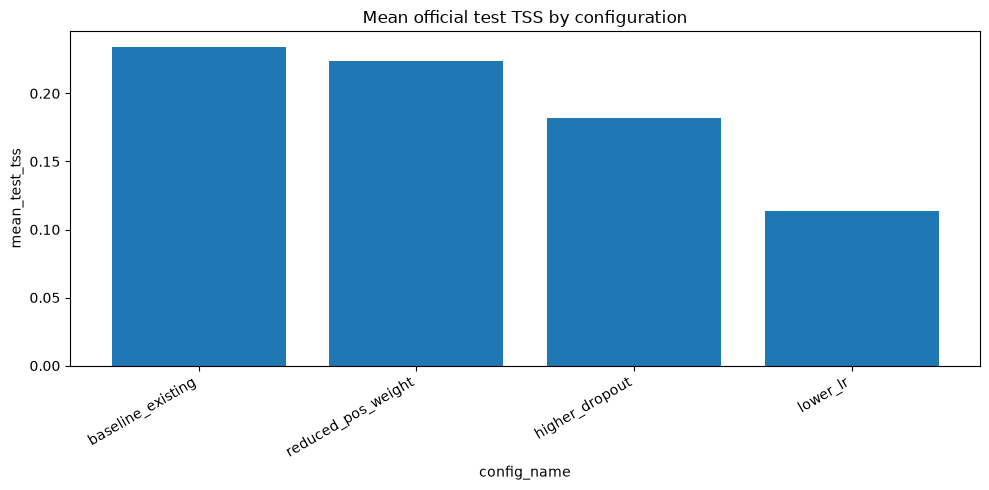

Saved: /home/abmoses2000/solar_flare_aia/results/figures/aia_resnet18_error_analysis_mean_test_tss_by_config.png


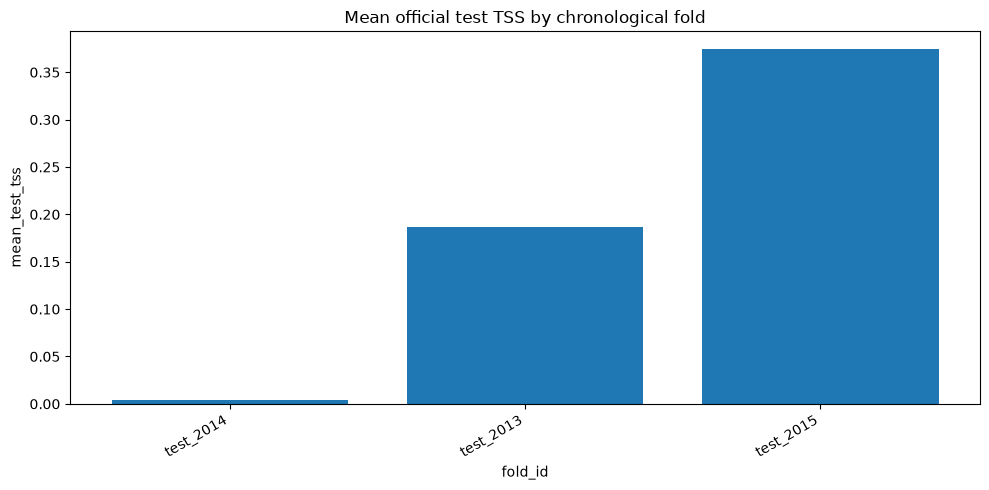

Saved: /home/abmoses2000/solar_flare_aia/results/figures/aia_resnet18_error_analysis_fold_hardness_tss.png


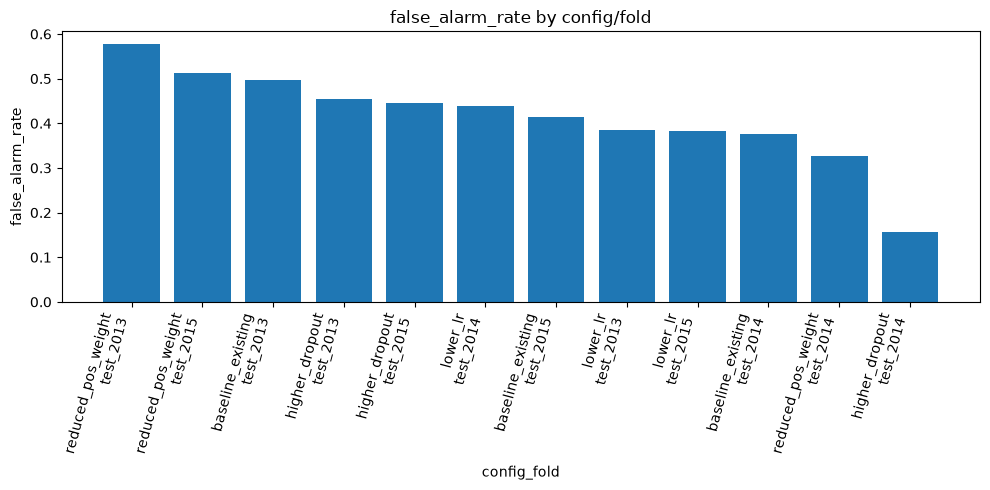

Saved: /home/abmoses2000/solar_flare_aia/results/figures/aia_resnet18_error_analysis_false_alarm_rate_by_config_fold.png


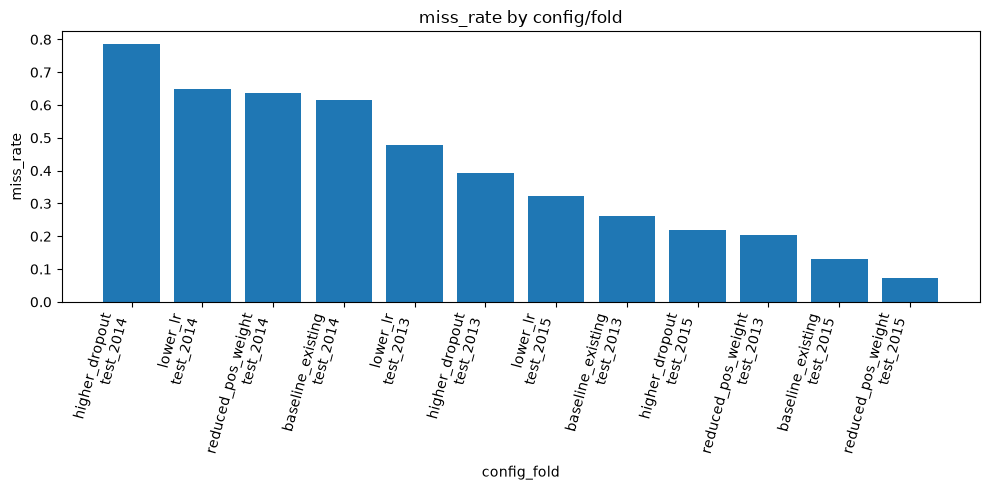

Saved: /home/abmoses2000/solar_flare_aia/results/figures/aia_resnet18_error_analysis_miss_rate_by_config_fold.png


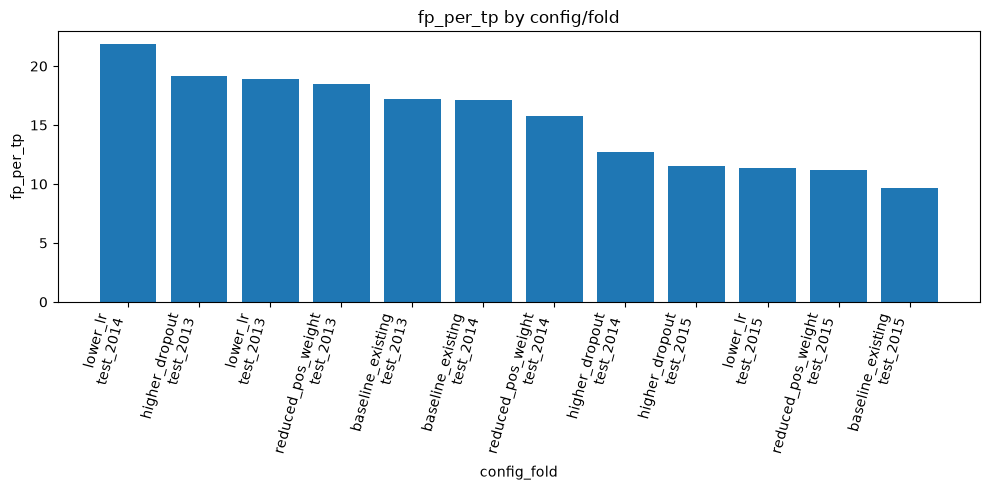

Saved: /home/abmoses2000/solar_flare_aia/results/figures/aia_resnet18_error_analysis_fp_per_tp_by_config_fold.png


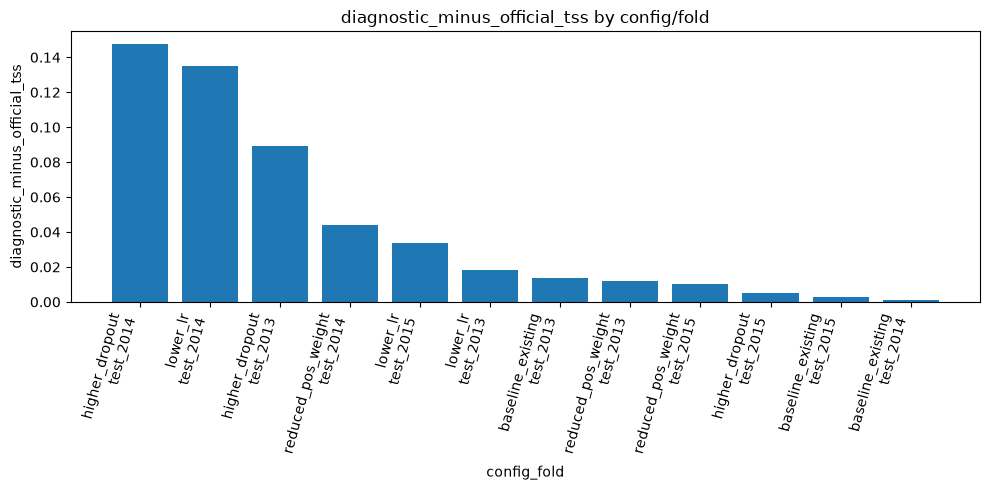

Saved: /home/abmoses2000/solar_flare_aia/results/figures/aia_resnet18_error_analysis_diagnostic_minus_official_tss_by_config_fold.png


In [8]:
import matplotlib.pyplot as plt

def save_bar(df, x, y, title, filename, rotation=30):
    fig = plt.figure(figsize=(10, 5))
    plt.bar(df[x].astype(str), df[y])
    plt.title(title)
    plt.xlabel(x)
    plt.ylabel(y)
    plt.xticks(rotation=rotation, ha="right")
    plt.tight_layout()
    path = FIG_DIR / filename
    plt.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()
    print("Saved:", path)

cfg_tss = (
    error_summary.groupby("config_name", as_index=False)
    .agg(mean_test_tss=("test_tss", "mean"), std_test_tss=("test_tss", "std"))
    .sort_values("mean_test_tss", ascending=False)
)
save_bar(cfg_tss, "config_name", "mean_test_tss",
         "Mean official test TSS by configuration", 
         "aia_resnet18_error_analysis_mean_test_tss_by_config.png")

save_bar(fold_hardness, "fold_id", "mean_test_tss",
         "Mean official test TSS by chronological fold", 
         "aia_resnet18_error_analysis_fold_hardness_tss.png")

tmp = error_summary.copy()
tmp["config_fold"] = tmp["config_name"].astype(str) + "\n" + tmp["fold_id"].astype(str)
for metric in ["false_alarm_rate", "miss_rate", "fp_per_tp", "diagnostic_minus_official_tss"]:
    plot_df = tmp.sort_values(metric, ascending=False)
    save_bar(plot_df, "config_fold", metric,
             f"{metric} by config/fold", 
             f"aia_resnet18_error_analysis_{metric}_by_config_fold.png",
             rotation=75)


## 8. Generate concise research log update

In [9]:
def fmt(x, nd=4):
    try:
        if pd.isna(x):
            return "NA"
        return f"{float(x):.{nd}f}"
    except Exception:
        return str(x)

selected_row = config_summary.sort_values("val_tss_mean", ascending=False).iloc[0]
baseline_row = config_summary[config_summary["config_name"] == "baseline_existing"]
baseline_text = ""
if len(baseline_row):
    b = baseline_row.iloc[0]
    baseline_text = (
        f" The existing baseline had mean validation TSS={fmt(b.get('val_tss_mean'))} "
        f"and mean official test TSS={fmt(b.get('test_tss_mean'))}."
    )

hardest_fold = fold_hardness.iloc[0]
best_test_cfg = config_summary.sort_values("test_tss_mean", ascending=False).iloc[0]

timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

research_log_text = f"""
## Research log update — ResNet18 physics-safe multifold hyperparameter sensitivity and error analysis

**Timestamp:** {timestamp}

### Experiment completed

Completed CPU post-analysis for `12_aia_resnet18_multifold_error_analysis_and_research_log_update.ipynb`, following the completed Notebook 12 hyperparameter sensitivity experiment.

The hyperparameter sensitivity study used a predefined, physics-safe search over:

- `lower_lr`
- `higher_dropout`
- `reduced_pos_weight`
- existing baseline comparison

Selection was based only on **mean validation TSS across chronological folds**. Test metrics were reported after selection and were not used to choose the configuration.

### Validation-selected configuration

The validation-selected configuration was **`{selected_row.get('config_name')}`**, with:

- Mean validation TSS: {fmt(selected_row.get('val_tss_mean'))} ± {fmt(selected_row.get('val_tss_std'))}
- Mean validation ROC-AUC: {fmt(selected_row.get('val_roc_auc_mean'))} ± {fmt(selected_row.get('val_roc_auc_std'))}
- Mean validation PR-AUC: {fmt(selected_row.get('val_pr_auc_mean'))} ± {fmt(selected_row.get('val_pr_auc_std'))}

Official test performance for the validation-selected configuration:

- Mean test TSS: {fmt(selected_row.get('test_tss_mean'))} ± {fmt(selected_row.get('test_tss_std'))}
- Mean test ROC-AUC: {fmt(selected_row.get('test_roc_auc_mean'))} ± {fmt(selected_row.get('test_roc_auc_std'))}
- Mean test PR-AUC: {fmt(selected_row.get('test_pr_auc_mean'))} ± {fmt(selected_row.get('test_pr_auc_std'))}
- Mean recall: {fmt(selected_row.get('test_recall_mean'))} ± {fmt(selected_row.get('test_recall_std'))}
- Mean specificity: {fmt(selected_row.get('test_specificity_mean'))} ± {fmt(selected_row.get('test_specificity_std'))}
{baseline_text}

### Error-analysis finding

The hardest chronological fold was **`{hardest_fold.get('fold_id')}`**, with mean official test TSS={fmt(hardest_fold.get('mean_test_tss'))}. This confirms that the weak fold is not fully corrected by small hyperparameter changes.

The highest mean official test TSS across configurations was observed for **`{best_test_cfg.get('config_name')}`** with mean official test TSS={fmt(best_test_cfg.get('test_tss_mean'))}. This is reported as analysis only, not as the selection criterion.

### Scientific interpretation

The controlled sensitivity study suggests that higher dropout can improve validation stability, but image-only AIA ResNet18 remains unstable across chronological folds. The weakness of the 2014 fold persists after tuning, supporting the interpretation that the limitation is not only architecture or hyperparameter choice. It is likely linked to chronological/solar-cycle phase shift and the limited information content of single-time AIA EUV cutouts.

### Next research step

Proceed to a multimodal, physics-aware stage:

1. Keep AIA imagery as a morphology/thermal-emission branch.
2. Add SHARP magnetic temporal features as a magnetic-evolution branch.
3. Include chronological/cycle-phase analysis as a regime diagnostic.
4. Preserve the official protocol: validation-selected threshold, chronological folds, no test-set tuning.

### Files generated

- `results/metrics/aia_resnet18_multifold_error_analysis_confusion_summary.csv`
- `results/metrics/aia_resnet18_multifold_error_analysis_fold_hardness.csv`
- `results/metrics/aia_resnet18_multifold_error_analysis_threshold_transfer.csv`
- `results/metrics/aia_resnet18_multifold_error_analysis_labelled_test_predictions.csv` if prediction files were available
- `results/metrics/aia_resnet18_multifold_error_analysis_top_false_positives_selected_config.csv` if prediction files were available
- `results/metrics/aia_resnet18_multifold_error_analysis_top_false_negatives_selected_config.csv` if prediction files were available
- `results/metrics/aia_resnet18_multifold_error_analysis_research_log_update.md`
- `results/figures/aia_resnet18_error_analysis_*.png`
""".strip()

out_log = OUT_DIR / "aia_resnet18_multifold_error_analysis_research_log_update.md"
out_log.write_text(research_log_text, encoding="utf-8")

print(research_log_text)
print("\nSaved:", out_log)


## Research log update — ResNet18 physics-safe multifold hyperparameter sensitivity and error analysis

**Timestamp:** 2026-08-03 12:36:30

### Experiment completed

Completed CPU post-analysis for `12_aia_resnet18_multifold_error_analysis_and_research_log_update.ipynb`, following the completed Notebook 12 hyperparameter sensitivity experiment.

The hyperparameter sensitivity study used a predefined, physics-safe search over:

- `lower_lr`
- `higher_dropout`
- `reduced_pos_weight`
- existing baseline comparison

Selection was based only on **mean validation TSS across chronological folds**. Test metrics were reported after selection and were not used to choose the configuration.

### Validation-selected configuration

The validation-selected configuration was **`higher_dropout`**, with:

- Mean validation TSS: 0.2403 ± 0.0219
- Mean validation ROC-AUC: 0.6480 ± 0.0355
- Mean validation PR-AUC: 0.0845 ± 0.0070

Official test performance for the validation-selected configuration:

- Mean

## 9. Final file inventory

In [10]:
generated_patterns = [
    "aia_resnet18_multifold_error_analysis_*.csv",
    "aia_resnet18_multifold_error_analysis_*.md",
]
print("Generated metrics/log files:")
for pat in generated_patterns:
    for p in sorted(OUT_DIR.glob(pat)):
        print(" -", p, f"({p.stat().st_size/1024:.1f} KiB)")

print("\nGenerated figures:")
for p in sorted(FIG_DIR.glob("aia_resnet18_error_analysis_*.png")):
    print(" -", p, f"({p.stat().st_size/1024:.1f} KiB)")

print("\nFinished:", datetime.now().isoformat(timespec="seconds"))


Generated metrics/log files:
 - /home/abmoses2000/solar_flare_aia/results/metrics/aia_resnet18_multifold_error_analysis_confusion_summary.csv (4.0 KiB)
 - /home/abmoses2000/solar_flare_aia/results/metrics/aia_resnet18_multifold_error_analysis_fold_hardness.csv (0.6 KiB)
 - /home/abmoses2000/solar_flare_aia/results/metrics/aia_resnet18_multifold_error_analysis_labelled_test_predictions.csv (48645.1 KiB)
 - /home/abmoses2000/solar_flare_aia/results/metrics/aia_resnet18_multifold_error_analysis_threshold_transfer.csv (1.4 KiB)
 - /home/abmoses2000/solar_flare_aia/results/metrics/aia_resnet18_multifold_error_analysis_top_false_negatives_selected_config.csv (35.5 KiB)
 - /home/abmoses2000/solar_flare_aia/results/metrics/aia_resnet18_multifold_error_analysis_top_false_positives_selected_config.csv (35.5 KiB)
 - /home/abmoses2000/solar_flare_aia/results/metrics/aia_resnet18_multifold_error_analysis_research_log_update.md (3.2 KiB)

Generated figures:
 - /home/abmoses2000/solar_flare_aia/resul